<img src="./pic/sharif-main-logo.png" alt="SUT logo" width=345 height=345 align=left class="saturate">


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Machine Learning <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2024<br>
<font color=3C99D size=5>
    Practical Assignment 2 - Unsupervised Learning<br>
<font color=696880 size=4>
    Assignment Supervisor: Niki Sepasian <br>
<font color=696880 size=5>
    Sarina Heshmati


In [2]:
student_number = 401102789
full_name = 'Seyed Ali Vakilzadeh'
assert student_number and full_name is not None, 'please input your information'

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualizations
sns.set(style="whitegrid")

## Overview

In this assignment, you will explore a dataset containing information about employees and use that data to train models capable of predicting whether those employees have left the company (attrited) or not. You will start by exploring the dataset, analyzing its features, and performing necessary preprocessing steps (such as label encoding and scaling). Then, you will build and evaluate implementations of K-Nearest Neighbors (KNN) as well as Random Forest, Bagging, and AdaBoost classifiers. After training and tuning each model, you’ll compare their performance using metrics like accuracy and feature importance to identify the best approach for accurate attrition prediction.

# Load and Explore Dataset (10 points)

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/ML_Practicals/HW2/Practical1/dataset.csv"
# Load the dataset
# "Attrition" is our target columm

df = pd.read_csv(file_path)
df.head(5)

Mounted at /content/drive


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,29,No,Travel_Rarely,592,Research & Development,7,3,Life Sciences,1,1883,...,2,80,0,11,2,3,3,2,1,2
1,34,No,Travel_Rarely,1326,Sales,3,3,Other,1,1478,...,4,80,0,15,2,3,13,9,3,12
2,27,No,Travel_Rarely,954,Sales,9,3,Marketing,1,1965,...,1,80,0,7,5,3,7,7,0,7
3,32,No,Travel_Rarely,929,Sales,10,3,Marketing,1,722,...,4,80,0,10,2,2,10,7,0,8
4,50,No,Travel_Frequently,1234,Research & Development,20,5,Medical,1,1606,...,3,80,1,32,3,3,30,8,12,13


Explore the dataset and get familiar with its features and statistics. (don't worry about the 'masked values' in our target column. They are simply used to automatically test your model later on.)

**** Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       902 non-null    int64 
 1   Attrition                 902 non-null    object
 2   BusinessTravel            902 non-null    object
 3   DailyRate                 902 non-null    int64 
 4   Department                902 non-null    object
 5   DistanceFromHome          902 non-null    int64 
 6   Education                 902 non-null    int64 
 7   EducationField            902 non-null    object
 8   EmployeeCount             902 non-null    int64 
 9   EmployeeNumber            902 non-null    int64 
 10  EnvironmentSatisfaction   902 non-null    int64 
 11  Gender                    902 non-null    object
 12  HourlyRate                902 non-null    int64 
 13  JobInvolvement            902 non-null    int64 
 14  JobLevel       

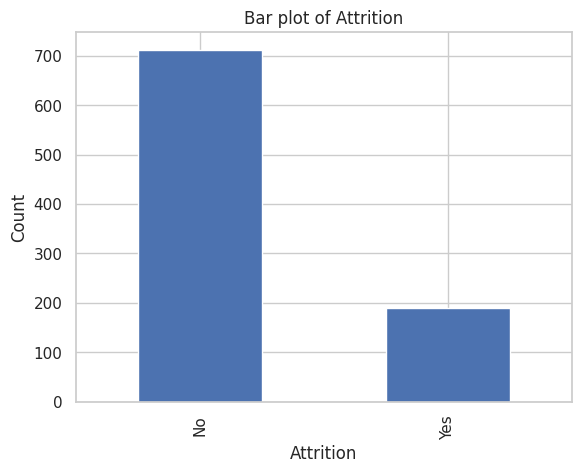

****Head: 
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   29        No      Travel_Rarely        592  Research & Development   
1   34        No      Travel_Rarely       1326                   Sales   
2   27        No      Travel_Rarely        954                   Sales   
3   32        No      Travel_Rarely        929                   Sales   
4   50        No  Travel_Frequently       1234  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 7          3  Life Sciences              1            1883   
1                 3          3          Other              1            1478   
2                 9          3      Marketing              1            1965   
3                10          3      Marketing              1             722   
4                20          5        Medical              1            1606   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [4]:
# TODO: Check the basic structure of the dataset using .info() and .describe()
print('**** Info:')
print(df.info())

# Use: df.info() to check data types and missing values
# Use: df.describe() to get summary statistics of numeric features
print('**** Description:')
print(df.describe())

# TODO: Check for any missing values in the dataset
# Use: df.isnull().sum() to find if any column has missing values
print('**** Sum:')
print(df.isnull().sum())


# TODO: Explore the target variable (binary classification)
# Use value_counts() to see the distribution of our target (Attrition) column and then visualize it (bar plot).
print('**** Value counts for attrition:')
print(df['Attrition'].value_counts())

df['Attrition'].value_counts().plot(kind='bar')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.title('Bar plot of Attrition')
plt.show()



print('****Head: ')
print(df.head())


It is generally better to remove columns with only one unique value from a DataFrame when preparing data for a decision tree. <br>
Such columns do not provide any useful information for splitting the data and can lead to unnecessary complexity in the model. Remove the said columns from the DataFrame.

In [5]:
# TODO Measure and print the number of unique values for each column.
# Check if there are any columns with less than 2 unique values. If so, remove them.
column_names = df.columns.tolist()
for name in column_names:
  num_unique_values = df[name].nunique()
  print(name , num_unique_values)
  if(num_unique_values < 2):
    df=df.drop(columns=[name])


Age 42
Attrition 2
BusinessTravel 3
DailyRate 653
Department 3
DistanceFromHome 29
Education 5
EducationField 6
EmployeeCount 1
EmployeeNumber 902
EnvironmentSatisfaction 4
Gender 2
HourlyRate 71
JobInvolvement 4
JobLevel 5
JobRole 9
JobSatisfaction 4
MaritalStatus 3
MonthlyIncome 853
MonthlyRate 888
NumCompaniesWorked 10
Over18 1
OverTime 2
PercentSalaryHike 15
PerformanceRating 2
RelationshipSatisfaction 4
StandardHours 1
StockOptionLevel 4
TotalWorkingYears 40
TrainingTimesLastYear 7
WorkLifeBalance 4
YearsAtCompany 34
YearsInCurrentRole 19
YearsSinceLastPromotion 16
YearsWithCurrManager 17


Look at the DataFrame and try to gather insight into people's monthly income and things that generally affect this number.

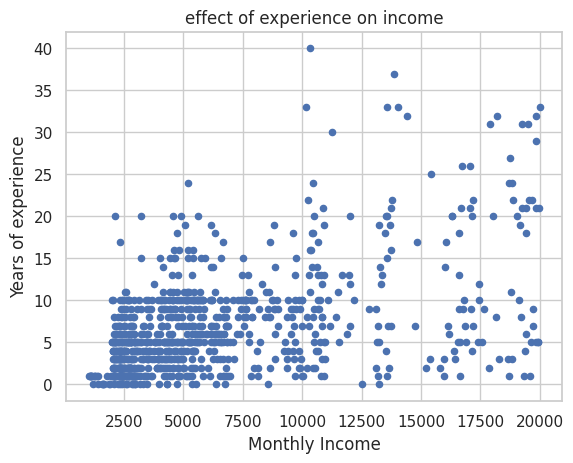

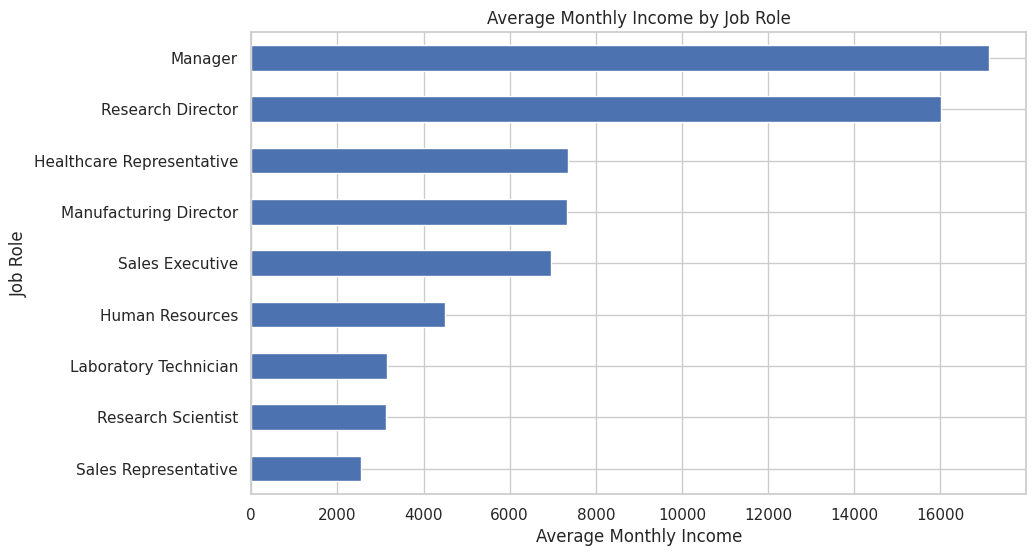

In [6]:
# TODO: Plot (lineplot) the average MonthlyIncome against the YearsAtCompany.
df.plot(x='MonthlyIncome', y='YearsAtCompany', kind='scatter')
plt.xlabel('Monthly Income')
plt.ylabel('Years of experience')
plt.title('effect of experience on income')
plt.show()
# TODO: Then find which departments have the highest and lowest incomes on average.

average_income = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values()

plt.figure(figsize=(10, 6))
average_income.plot(kind='barh')
plt.xlabel('Average Monthly Income')
plt.ylabel('Job Role')
plt.title('Average Monthly Income by Job Role')
plt.show()

# Data Preprocessing (5 points)

Label Encode categorical columns and create a new DataFrame. Then split this data into train and test.

In [7]:
# Split into features and target variable
X = df.drop(columns=['Attrition'])
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_test = y_test.map({'No': 0, 'Yes': 1}).values
y_train = y_train.map({'No': 0, 'Yes': 1}).values
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Initialize LabelEncoders for categorical columns
label_encoders = {col: LabelEncoder() for col in categorical_cols}

# Encode categorical columns in training and test sets
for col, encoder in label_encoders.items():
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

# Initialize and apply StandardScaler to numerical columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train_scaled= X_train
X_test_scaled= X_test
print(X_test_scaled['Age'].info())


<class 'pandas.core.series.Series'>
Index: 271 entries, 70 to 465
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
271 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB
None


# K-Nearest Neighbors (KNN) Model (15 points)

Implement KNN model from scratch.

In [8]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score

class CustomKNN:
    def __init__(self, k):
        """
        Initialize the KNN classifier.

        Parameters:
        - k (int): Number of neighbors to consider.
        """
        # Store the number of neighbors (k)
        self.k = k

    def fit(self, X_train, y_train):
        """
        Fit the KNN classifier to the training data.

        Parameters:
        - X_train (numpy array): Training feature vectors.
        - y_train (numpy array): Training labels.
        """
        # Store training data
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def euclidean_distance(self, x1, x2):
        """
        Calculate the Euclidean distance between two data points.

        Parameters:
        - x1 (numpy array): First data point.
        - x2 (numpy array): Second data point.

        Returns:
        - float: Euclidean distance between x1 and x2.
        """
        return  np.linalg.norm((x1 - x2))

    def predict(self, X_test):
        """
        Predict labels for test data.

        Parameters:
        - X_test (numpy array): Test feature vectors.

        Returns:
        - numpy array: Predicted labels.
        """
        predictions = []
        # Iterate through each test sample
        for test_sample in X_test:
            prediction = self._predict(test_sample)
            predictions.append(prediction)

        return np.array(predictions)

    def _predict(self, x):
        """
        Predict label for a single data point.

        Parameters:
        - x (numpy array): Test data point.

        Returns:
        - int: Predicted label.
        """
        distances=np.zeros(self.X_train.shape[0])
        distance_index_array= np.empty(self.X_train.shape[0], dtype=object)
        i=0
        for training_x in self.X_train:
          distance= self.euclidean_distance(x, training_x)
          distances[i]= distance
          distance_index_array[i]= (distance, i)
          i+=1
        distance_index_array= distance_index_array[np.argsort(distances)]
        votes=0
        for i in range(self.k):
           if(self.y_train[distance_index_array[i][1]] ==1):
              votes+=1

        if(votes > self.k // 2):
          return 1
        else:
          return 0


Fit and test your model using different k values and then choose the best one.

In [9]:
# Optional. You can choose any range of k values that you want.
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
accuracies = []
knn_accuracy_model_pairs = []
from sklearn.metrics import recall_score

for k in k_values:
    y_pred_custom= []
    Knn_model= CustomKNN(k)
    Knn_model.fit(X_train_scaled.values, y_train)
    y_pred_custom = Knn_model.predict(X_test_scaled.values)
    accuracy = accuracy_score(y_test, y_pred_custom)
    accuracies.append(accuracy)
    knn_accuracy_model_pairs.append((accuracy, Knn_model))
    recall = recall_score(y_test, y_pred_custom, pos_label=1)
    print(f'k: {k} - Accuracy: {accuracy_score(y_test, y_pred_custom)} ,Recall: {recall:.2f}')

knn_accuracy_model_pairs.sort(key=lambda item: item[0], reverse=True)
Best_custom_model= knn_accuracy_model_pairs[0][1]

# Keep the best k value (needed later on with bagging)
bestk= Best_custom_model.k

k: 1 - Accuracy: 0.7896678966789668 ,Recall: 0.42
k: 3 - Accuracy: 0.7970479704797048 ,Recall: 0.24
k: 5 - Accuracy: 0.7970479704797048 ,Recall: 0.16
k: 7 - Accuracy: 0.7970479704797048 ,Recall: 0.11
k: 9 - Accuracy: 0.7970479704797048 ,Recall: 0.13
k: 11 - Accuracy: 0.7970479704797048 ,Recall: 0.11
k: 13 - Accuracy: 0.8081180811808119 ,Recall: 0.11
k: 15 - Accuracy: 0.8007380073800738 ,Recall: 0.09


In [10]:
# TODO: Print the accuracy and classification report using sklearn's metrics for your best model
y_pred= Best_custom_model.predict(X_test_scaled.values)
accuracy = accuracy_score(y_test, y_pred)
#accuracy:
print(f"Accuracy: {accuracy:.2f}")

#classification report:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       216
           1       0.67      0.11      0.19        55

    accuracy                           0.81       271
   macro avg       0.74      0.55      0.54       271
weighted avg       0.78      0.81      0.75       271



Visualize the confusion matrix for KNN predictions

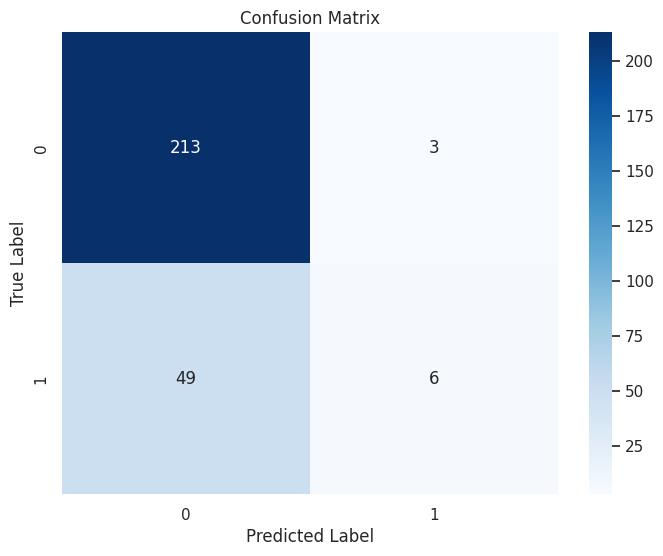

In [11]:
# TODO: Create a confusion matrix for KNN predictions
# Use confusion_matrix from sklearn.metrics
confusion_matrix_knn= confusion_matrix(y_test, y_pred)

# TODO: Visualize the confusion matrix using seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Evaluation (30 points)
In this part, we are going to evaluate your model's performance on another set of unseen data. Load test.csv (this data is already encoded), use your best_custom_model to predict and save the results in a DataFrame called 'result.csv'. The DataFrame should contain one column called 'target' that contains your model's predictions.

In [15]:
# Load test.csv
file_path = "/content/drive/My Drive/ML_Practicals/HW2/Practical1/test.csv"
eval_df= pd.read_csv(file_path)

X2 = scaler.fit_transform(eval_df)
test_knn = CustomKNN( bestk)
test_knn.fit(X_train, y_train)
y_pred_eval = test_knn.predict(X2)

Save the results in a DataFrame

In [17]:
# Save the results as a csv file
result_df= pd.DataFrame()
result_df['target']=pd.Series(y_pred_eval)
result_df.to_csv("/content/drive/My Drive/ML_Practicals/HW2/Practical1/result.csv", index= False)

# Random Forest Model (12 points)

Implement a random forest model using sklearn.

In [18]:
# TODO: Implement the Random Forest model
rf = RandomForestClassifier(random_state=42)

# TODO: Set up a hyperparameter tuning process for Random Forest using GridSearchCV
# Suggested parameter grid: {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}

# GridSearchCV with Random Forest
rf_cv = GridSearchCV(rf, param_grid_rf, cv=5)

# TODO: Fit the GridSearchCV on the training data to find the best parameters
rf_cv.fit(X_train_scaled, y_train)

# TODO: Use the best Random Forest model for predictions on the test data
best_rf = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

# TODO: Print the Random Forest model accuracy and classification report using sklearn's metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.8339483394833949
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       216
           1       0.78      0.25      0.38        55

    accuracy                           0.83       271
   macro avg       0.81      0.62      0.64       271
weighted avg       0.83      0.83      0.80       271



Visualize the confusion matrix for Random Forest predictions

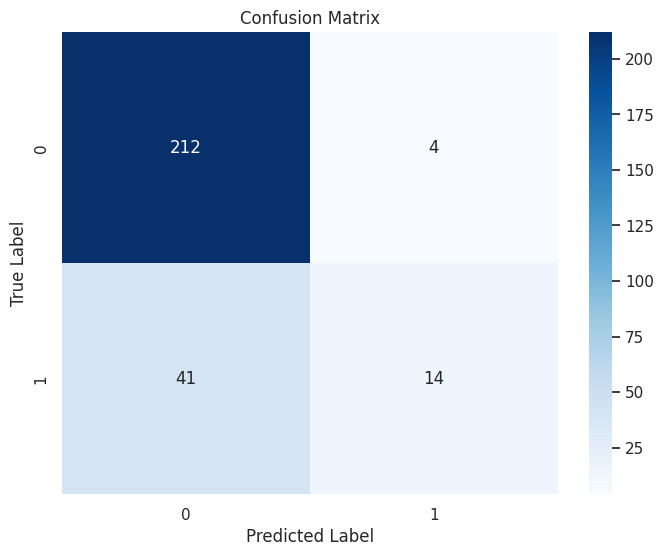

In [19]:
# TODO: Create a confusion matrix for Random Forest predictions
# Use confusion_matrix from sklearn.metrics
confusion_matrix_rf= confusion_matrix(y_test, y_pred_rf)


# TODO: Visualize the confusion matrix using seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
# Add annotations and a title for better readability
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

A feature importance plot is a visual representation that illustrates the significance of each feature (or variable) in a machine learning model, particularly in the context of supervised learning tasks like classification and regression. Plot the feature importances using a bar plot.

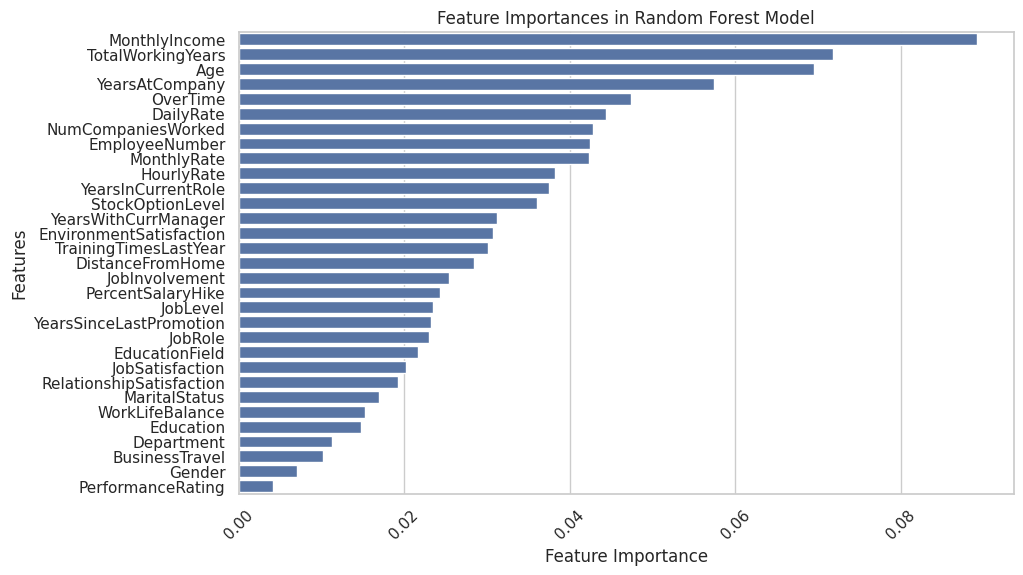

In [20]:
# Get the feature importances from the trained Random Forest model
importances= best_rf.feature_importances_

# TODO: Sort the indices of the importance values in descending order
sorted_indices = np.argsort(importances)[::-1]
# TODO: Create a DataFrame that contains the feature names and their corresponding importance scores
feature_names = X.columns  # assuming X is the feature DataFrame used in training
importance_df = pd.DataFrame({
    'Feature': feature_names[sorted_indices],
    'Importance': importances[sorted_indices]
})
# TODO: Create a bar plot to visualize feature importances using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)


# use tick_params and Rotate the x-axis labels for better readability
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importances in Random Forest Model')
plt.xticks(rotation=45)
plt.tick_params(axis='x', rotation=45)
plt.show()

# Bagging with KNN (12 points)

In [21]:
# TODO: Implement Bagging with KNN
# Use BaggingClassifier with KNeighborsClassifier as the base estimator
# Here we use the bestk value we found before

bagging_knn = BaggingClassifier(KNeighborsClassifier(n_neighbors=bestk), n_estimators=50, random_state=42)

# TODO: Fit the BaggingClassifier on the scaled training data
bagging_knn.fit(X_train_scaled, y_train)
# Use bagging_knn.fit() with the training data

# TODO: Use the trained Bagging model for predictions on the test data
# Use bagging_knn.predict()
y_pred_bagging = bagging_knn.predict(X_test_scaled)

# TODO: Print the Bagging KNN model accuracy and classification report
# Use accuracy_score and classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_bagging))

Accuracy: 0.8118081180811808
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       216
           1       0.75      0.11      0.19        55

    accuracy                           0.81       271
   macro avg       0.78      0.55      0.54       271
weighted avg       0.80      0.81      0.75       271



Visualize the confusion matrix for Baggin KNN predictions

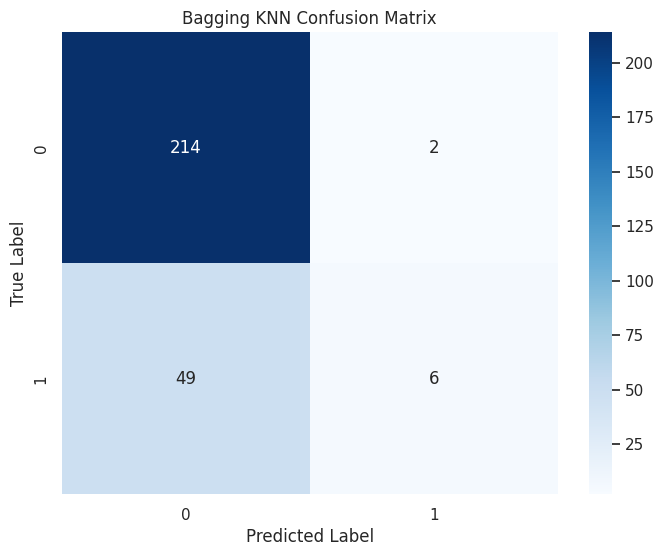

In [26]:
# TODO: Create a confusion matrix for Bagging KNN predictions
# Use confusion_matrix from sklearn.metrics
confusion_matrix_bagging= confusion_matrix(y_test, y_pred_bagging)

# TODO: Visualize the confusion matrix using seaborn's heatmap
# Add annotations and a title for better readability
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_bagging, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Bagging KNN Confusion Matrix')
plt.show()

# AdaBoost Model (12 points)

In [24]:
# TODO: Implement AdaBoost model
adaboost = AdaBoostClassifier(random_state=42)

# TODO: Set up a hyperparameter tuning process for AdaBoost using GridSearchCV
# Suggested parameter grid: {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 1.0]}
param_grid_ada = {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 1.0]}

# GridSearchCV with AdaBoost
adaboost_cv = GridSearchCV(adaboost, param_grid_ada, cv=5)

# TODO: Fit the GridSearchCV on the training data to find the best parameters
# Use adaboost_cv.fit() with the training data
adaboost_cv.fit(X_train_scaled, y_train)

# TODO: Use the best AdaBoost model for predictions on the test data
# Use adaboost_cv.best_estimator_ and predict()
adaboost_best = adaboost_cv.best_estimator_
y_pred_ada = adaboost_best.predict(X_test_scaled)


# TODO: Print the AdaBoost model accuracy and classification report using sklearn's metrics
# Use accuracy_score and classification_report
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_ada))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

Accuracy: 0.8339483394833949
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.90       216
           1       0.81      0.24      0.37        55

    accuracy                           0.83       271
   macro avg       0.82      0.61      0.64       271
weighted avg       0.83      0.83      0.80       271



Visualize the confusion matrix for AdaBoost predictions

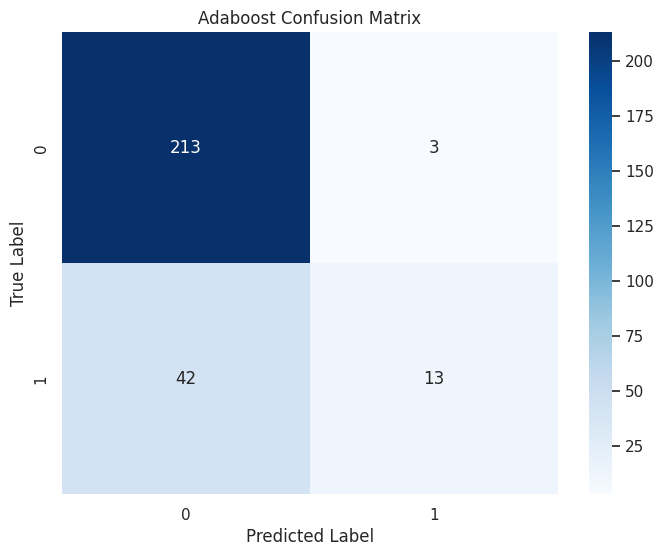

In [27]:
# TODO: Create a confusion matrix for AdaBoost predictions
# Use confusion_matrix from sklearn.metrics
confusion_matrix_ada= confusion_matrix(y_test, y_pred_ada)
# TODO: Visualize the confusion matrix using seaborn's heatmap
# Add annotations and a title for better readability
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_ada, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Adaboost Confusion Matrix')
plt.show()

# Model Comparison (4 points)

Text(0.5, 1.0, 'Model Comparison')

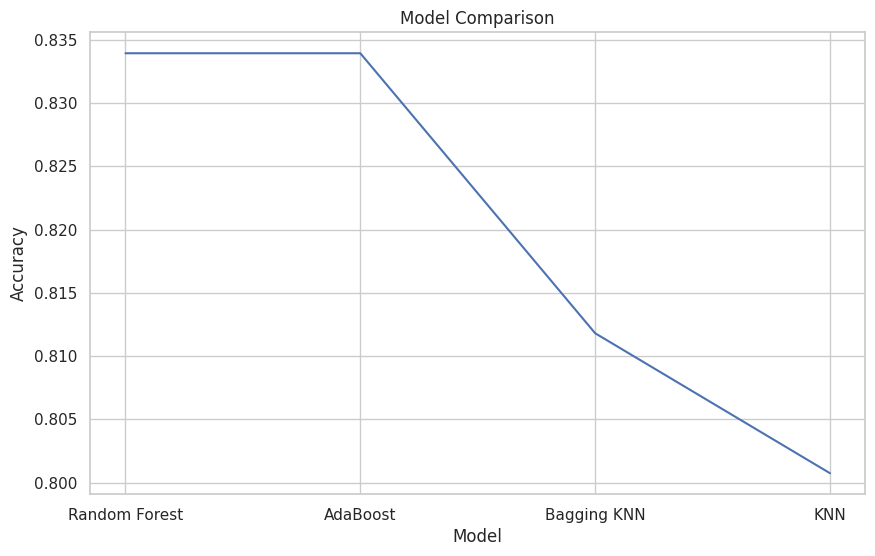

In [29]:
# TODO: Compare model accuracies for KNN, Random Forest, Bagging KNN, and AdaBoost
# Create a DataFrame with model names and their respective accuracies
model_accuracy_comparator= {}
model_accuracy_comparator['KNN'] = accuracy_score(y_test, y_pred_custom)
model_accuracy_comparator['Random Forest'] = accuracy_score(y_test, y_pred_rf)
model_accuracy_comparator['Bagging KNN'] = accuracy_score(y_test, y_pred_bagging)
model_accuracy_comparator['AdaBoost']= accuracy_score(y_test, y_pred_ada)
# Sort the DataFrame by accuracy in descending order
model_accuracy_comparator = {k: v for k, v in sorted(model_accuracy_comparator.items(), key=lambda item: item[1], reverse=True)}
models_dataframe= pd.DataFrame(model_accuracy_comparator.items(), columns=['Model', 'Accuracy'])
# TODO: Visualize the model comparison using a line plot
# Use seaborn's lineplot to plot model names vs. accuracies
plt.figure(figsize=(10, 6))
sns.lineplot(x='Model', y='Accuracy', data=models_dataframe)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')